<a href="https://colab.research.google.com/github/sanjanapstech-ui/AI-in-mobility/blob/main/AI_in_mobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import os

GOOGLE_DRIVE_FILE_ID = '1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz'
output_file_name = 'v1.0-mini.tgz'

!gdown --id {GOOGLE_DRIVE_FILE_ID} -O {output_file_name}

file_path = f'./{output_file_name}'
extract_dir = '/content/v1.0-mini'

if os.path.exists(file_path):
    print(f"File '{output_file_name}' downloaded successfully to: {os.getcwd()}")
else:
    print(f"Error: File '{output_file_name}' not found after download attempt.")

import tarfile
os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(file_path, 'r:gz') as tar:
    tar.extractall(path=extract_dir, filter='data')

print(f"File extracted to: {extract_dir}")

print("Contents of extracted directory (first 10 items):")
count = 0
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        if count < 10:
            print(os.path.join(root, name))
            count += 1
    for name in dirs:
        if count < 10:
            print(os.path.join(root, name))
            count += 1
    if count >= 10: break

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz
From (redirected): https://drive.google.com/uc?id=1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz&confirm=t&uuid=5c38c092-2783-4976-b788-998ef53697e2
To: /content/v1.0-mini.tgz
100% 4.17G/4.17G [00:34<00:00, 123MB/s]
File 'v1.0-mini.tgz' downloaded successfully to: /content
File extracted to: /content/v1.0-mini
Contents of extracted directory (first 10 items):
/content/v1.0-mini/.v1.0-mini.txt
/content/v1.0-mini/LICENSE
/content/v1.0-mini/maps
/content/v1.0-mini/sweeps
/content/v1.0-mini/v1.0-mini
/content/v1.0-mini/samples
/content/v1.0-mini/maps/93406b464a165eaba6d9de76ca09f5da.png
/content/v1.0-mini/maps/36092f0b03a857c6a3403e25b4b7aab3.png
/content/v1.0-mini/maps/37819e65e09e5547b8a3

note: if it asks for restart do it then run again.

In [44]:
import os
from nuscenes.nuscenes import NuScenes

dataroot = '/content/v1.0-mini'

try:
    nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)
    print("\nNuScenes dataset loaded successfully!")
except Exception as e:
    print(f"Error loading NuScenes dataset: {e}")
    print("Please ensure the 'v1.0-mini' folder structure is correct inside /content/v1.0-mini")

print("\nAvailable categories in nuScenes:")
for category in nusc.category:
    print(f"- {category['name']}")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.009 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.

NuScenes dataset loaded successfully!

Available categories in nuScenes:
- human.pedestrian.adult
- human.pedestrian.child
- human.pedestrian.wheelchair
- human.pedestrian.stroller
- human.pedestrian.personal_mobility
- human.pedestrian.police_officer
- human.pedestrian.construction_worker
- animal
- vehicle.car
- vehicle.motorcycle
- vehicle.bicycle
- vehicle.bus.bendy
- vehicle.bus.rigid
- vehicle.truck
- vehicle.construction
- vehicle.emergency.ambulance
- vehicle.emergency.police
- vehicle.trailer
- movable_object.barrier
- movable_object.trafficcone
- movable_object.pushable_pullable
- movable_object.debris
- static_object.bicycle_rack


Exploring Pedestrian and Cyclist Data

In [45]:
import numpy as np
from nuscenes.nuscenes import NuScenes
import os

dataroot = '/content/v1.0-mini'

if 'nusc' not in locals() or not isinstance(nusc, NuScenes):
    try:
        nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=False)
        print("NuScenes dataset re-initialized in this cell.")
    except Exception as e:
        print(f"Error re-initializing NuScenes dataset: {e}")
        print("Please ensure the 'v1.0-mini' folder structure is correct inside /content/v1.0-mini and the previous cells have been executed.")

ped_cyclist_categories = []
for category in nusc.category:
    if 'human.pedestrian' in category['name'] or 'vehicle.bicycle' in category['name']:
        ped_cyclist_categories.append(category['name'])

print(f"Pedestrian and cyclist categories: {ped_cyclist_categories}")

ped_cyclist_samples = set()
for sample_annotation in nusc.sample_annotation:
    if sample_annotation['category_name'] in ped_cyclist_categories:
        ped_cyclist_samples.add(sample_annotation['sample_token'])

print(f"Found {len(ped_cyclist_samples)} samples containing pedestrians or cyclists.")

print("\nFirst 5 sample tokens with pedestrians/cyclists:")
for i, sample_token in enumerate(list(ped_cyclist_samples)[:5]):
    sample = nusc.get('sample', sample_token)
    print(f"Sample {i+1}: token={sample_token}, timestamp={sample['timestamp']}")

    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        if ann['category_name'] in ped_cyclist_categories:
            print(f"  - Annotation: {ann['category_name']}, instance_token={ann['instance_token']}")

Pedestrian and cyclist categories: ['human.pedestrian.adult', 'human.pedestrian.child', 'human.pedestrian.wheelchair', 'human.pedestrian.stroller', 'human.pedestrian.personal_mobility', 'human.pedestrian.police_officer', 'human.pedestrian.construction_worker', 'vehicle.bicycle']
Found 327 samples containing pedestrians or cyclists.

First 5 sample tokens with pedestrians/cyclists:
Sample 1: token=67e5f88901214f3aa03d68e028185e22, timestamp=1532402945697148
  - Annotation: human.pedestrian.adult, instance_token=6dd2cbf4c24b4caeb625035869bca7b5
  - Annotation: human.pedestrian.construction_worker, instance_token=1bc410ff237c4c48b9b7b094a9eaeb4d
  - Annotation: human.pedestrian.adult, instance_token=1e775890010e4d97b74ca1d06441d023
  - Annotation: human.pedestrian.adult, instance_token=1511e02cbd80490299371149ed7eb269
  - Annotation: human.pedestrian.adult, instance_token=73ee514c205c483da3d1d04282337457
  - Annotation: vehicle.bicycle, instance_token=f0056532879643c69e4efc9d845782f0
  - 

Extracting a Full Trajectory for a Single Instance

In [46]:
import numpy as np
import pandas as pd
from nuscenes.nuscenes import NuScenes
import os

dataroot = '/content/v1.0-mini'
if 'nusc' not in locals() or not isinstance(nusc, NuScenes):
    try:
        nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=False)
        print("NuScenes dataset re-initialized in this cell.")
    except Exception as e:
        print(f"Error re-initializing NuScenes dataset: {e}")
        print("Please ensure the 'v1.0-mini' folder structure is correct inside /content/v1.0-mini and the previous cells have been executed.")

ped_cyclist_categories = []
for category in nusc.category:
    if 'human.pedestrian' in category['name'] or 'vehicle.bicycle' in category['name']:
        ped_cyclist_categories.append(category['name'])

ped_cyclist_samples = set()
for sample_annotation in nusc.sample_annotation:
    if sample_annotation['category_name'] in ped_cyclist_categories:
        ped_cyclist_samples.add(sample_annotation['sample_token'])

target_instance_token = '98e2b15c113a477a9f291b25194cab62'

if target_instance_token:
    print(f"Extracting full trajectory for instance: {target_instance_token}")
    target_instance = nusc.get('instance', target_instance_token)

    trajectory_data = []
    current_annotation_token = target_instance['first_annotation_token']

    while current_annotation_token:
        current_ann = nusc.get('sample_annotation', current_annotation_token)
        sample_record = nusc.get('sample', current_ann['sample_token'])
        timestamp_s = sample_record['timestamp'] / 1000000.0

        trajectory_data.append({
            'instance_token': target_instance_token,
            'category_name': current_ann['category_name'],
            'timestamp_s': timestamp_s,
            'x': current_ann['translation'][0],
            'y': current_ann['translation'][1],
            'z': current_ann['translation'][2]
        })
        current_annotation_token = current_ann['next']

    trajectory_df = pd.DataFrame(trajectory_data)

    print(f"Extracted {len(trajectory_df)} points for instance {target_instance_token}.")
    if not trajectory_df.empty:
        display(trajectory_df.head())
else:
    print("Could not find a pedestrian/cyclist instance to extract a trajectory.")

Extracting full trajectory for instance: 98e2b15c113a477a9f291b25194cab62
Extracted 18 points for instance 98e2b15c113a477a9f291b25194cab62.


,instance_token,category_name,timestamp_s,x,y,z
0,98e2b15c113a477a9f291b25194cab62,human.pedestrian.adult,1.542801e+09,1484.678,1155.766,2.115
1,98e2b15c113a477a9f291b25194cab62,human.pedestrian.adult,1.542801e+09,1484.811,1155.072,1.996
2,98e2b15c113a477a9f291b25194cab62,human.pedestrian.adult,1.542801e+09,1484.917,1154.448,1.890
3,98e2b15c113a477a9f291b25194cab62,human.pedestrian.adult,1.542801e+09,1485.024,1153.819,1.782
4,98e2b15c113a477a9f291b25194cab62,human.pedestrian.adult,1.542801e+09,1485.110,1153.208,1.675


Visualizing the Extracted Trajectory

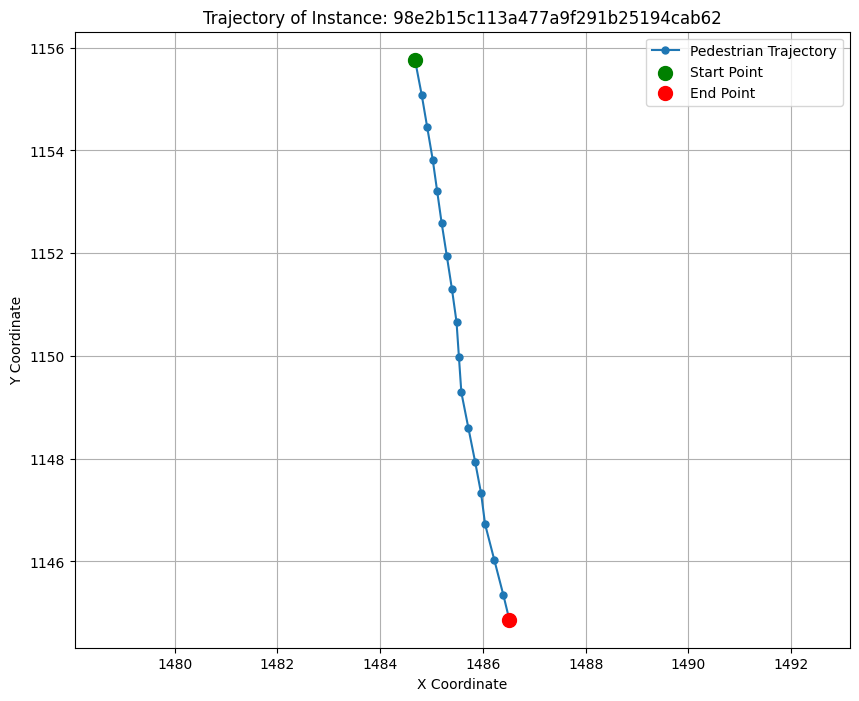

In [47]:
import matplotlib.pyplot as plt

if 'trajectory_df' in locals() and not trajectory_df.empty:
    plt.figure(figsize=(10, 8))
    plt.plot(trajectory_df['x'], trajectory_df['y'], marker='o', linestyle='-', markersize=5, label='Pedestrian Trajectory')
    plt.scatter(trajectory_df['x'].iloc[0], trajectory_df['y'].iloc[0], color='green', s=100, zorder=5, label='Start Point')
    plt.scatter(trajectory_df['x'].iloc[-1], trajectory_df['y'].iloc[-1], color='red', s=100, zorder=5, label='End Point')
    plt.title(f"Trajectory of Instance: {target_instance_token}")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()
else:
    print("No trajectory data found. Please run the trajectory extraction cell first.")

Extracting Trajectories for Multiple Instances

In [48]:
all_trajectories = {}

selected_sample_tokens = list(ped_cyclist_samples)[:5]

print(f"Extracted trajectories for instances in {len(selected_sample_tokens)} samples...")

for sample_token in selected_sample_tokens:
    sample = nusc.get('sample', sample_token)

    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)

        if ann['category_name'] in ped_cyclist_categories:
            instance_token = ann['instance_token']

            if instance_token not in all_trajectories:
                target_instance = nusc.get('instance', instance_token)
                trajectory_data = []
                current_annotation_token = target_instance['first_annotation_token']

                while current_annotation_token:
                    current_ann = nusc.get('sample_annotation', current_annotation_token)
                    sample_record = nusc.get('sample', current_ann['sample_token'])
                    timestamp_s = sample_record['timestamp'] / 1000000.0

                    trajectory_data.append({
                        'instance_token': instance_token,
                        'category_name': current_ann['category_name'],
                        'timestamp_s': timestamp_s,
                        'x': current_ann['translation'][0],
                        'y': current_ann['translation'][1],
                        'z': current_ann['translation'][2]
                    })
                    current_annotation_token = current_ann['next']

                if trajectory_data:
                    all_trajectories[instance_token] = pd.DataFrame(trajectory_data)

print(f"Extracted trajectories for {len(all_trajectories)} unique pedestrian/cyclist instances.")

print("\nFirst 3 extracted trajectories (first 5 points each):")
for i, (instance_token, df) in enumerate(all_trajectories.items()):
    if i >= 3:
        break
    print(f"\nInstance {instance_token} ({df['category_name'].iloc[0]}):")
    display(df.head())

Extracted trajectories for instances in 5 samples...
Extracted trajectories for 66 unique pedestrian/cyclist instances.

First 3 extracted trajectories (first 5 points each):

Instance 6dd2cbf4c24b4caeb625035869bca7b5 (human.pedestrian.adult):


,instance_token,category_name,timestamp_s,x,y,z
0,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.80
1,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.81
2,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.82
3,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.83
4,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.84



Instance 1bc410ff237c4c48b9b7b094a9eaeb4d (human.pedestrian.construction_worker):


,instance_token,category_name,timestamp_s,x,y,z
0,1bc410ff237c4c48b9b7b094a9eaeb4d,human.pedestrian.construction_worker,1.532403e+09,392.736,1113.268,1.023
1,1bc410ff237c4c48b9b7b094a9eaeb4d,human.pedestrian.construction_worker,1.532403e+09,392.753,1113.270,1.045
2,1bc410ff237c4c48b9b7b094a9eaeb4d,human.pedestrian.construction_worker,1.532403e+09,392.770,1113.271,1.067
3,1bc410ff237c4c48b9b7b094a9eaeb4d,human.pedestrian.construction_worker,1.532403e+09,392.787,1113.273,1.090
4,1bc410ff237c4c48b9b7b094a9eaeb4d,human.pedestrian.construction_worker,1.532403e+09,392.803,1113.274,1.112



Instance 1e775890010e4d97b74ca1d06441d023 (human.pedestrian.adult):


,instance_token,category_name,timestamp_s,x,y,z
0,1e775890010e4d97b74ca1d06441d023,human.pedestrian.adult,1.532403e+09,426.135,1115.102,1.889
1,1e775890010e4d97b74ca1d06441d023,human.pedestrian.adult,1.532403e+09,426.135,1115.102,1.901
2,1e775890010e4d97b74ca1d06441d023,human.pedestrian.adult,1.532403e+09,426.135,1115.102,1.914
3,1e775890010e4d97b74ca1d06441d023,human.pedestrian.adult,1.532403e+09,426.135,1115.102,1.926
4,1e775890010e4d97b74ca1d06441d023,human.pedestrian.adult,1.532403e+09,426.135,1115.102,1.939


Visualizing the Extracted Trajectory

Visualizing 5 of 66 extracted trajectories:


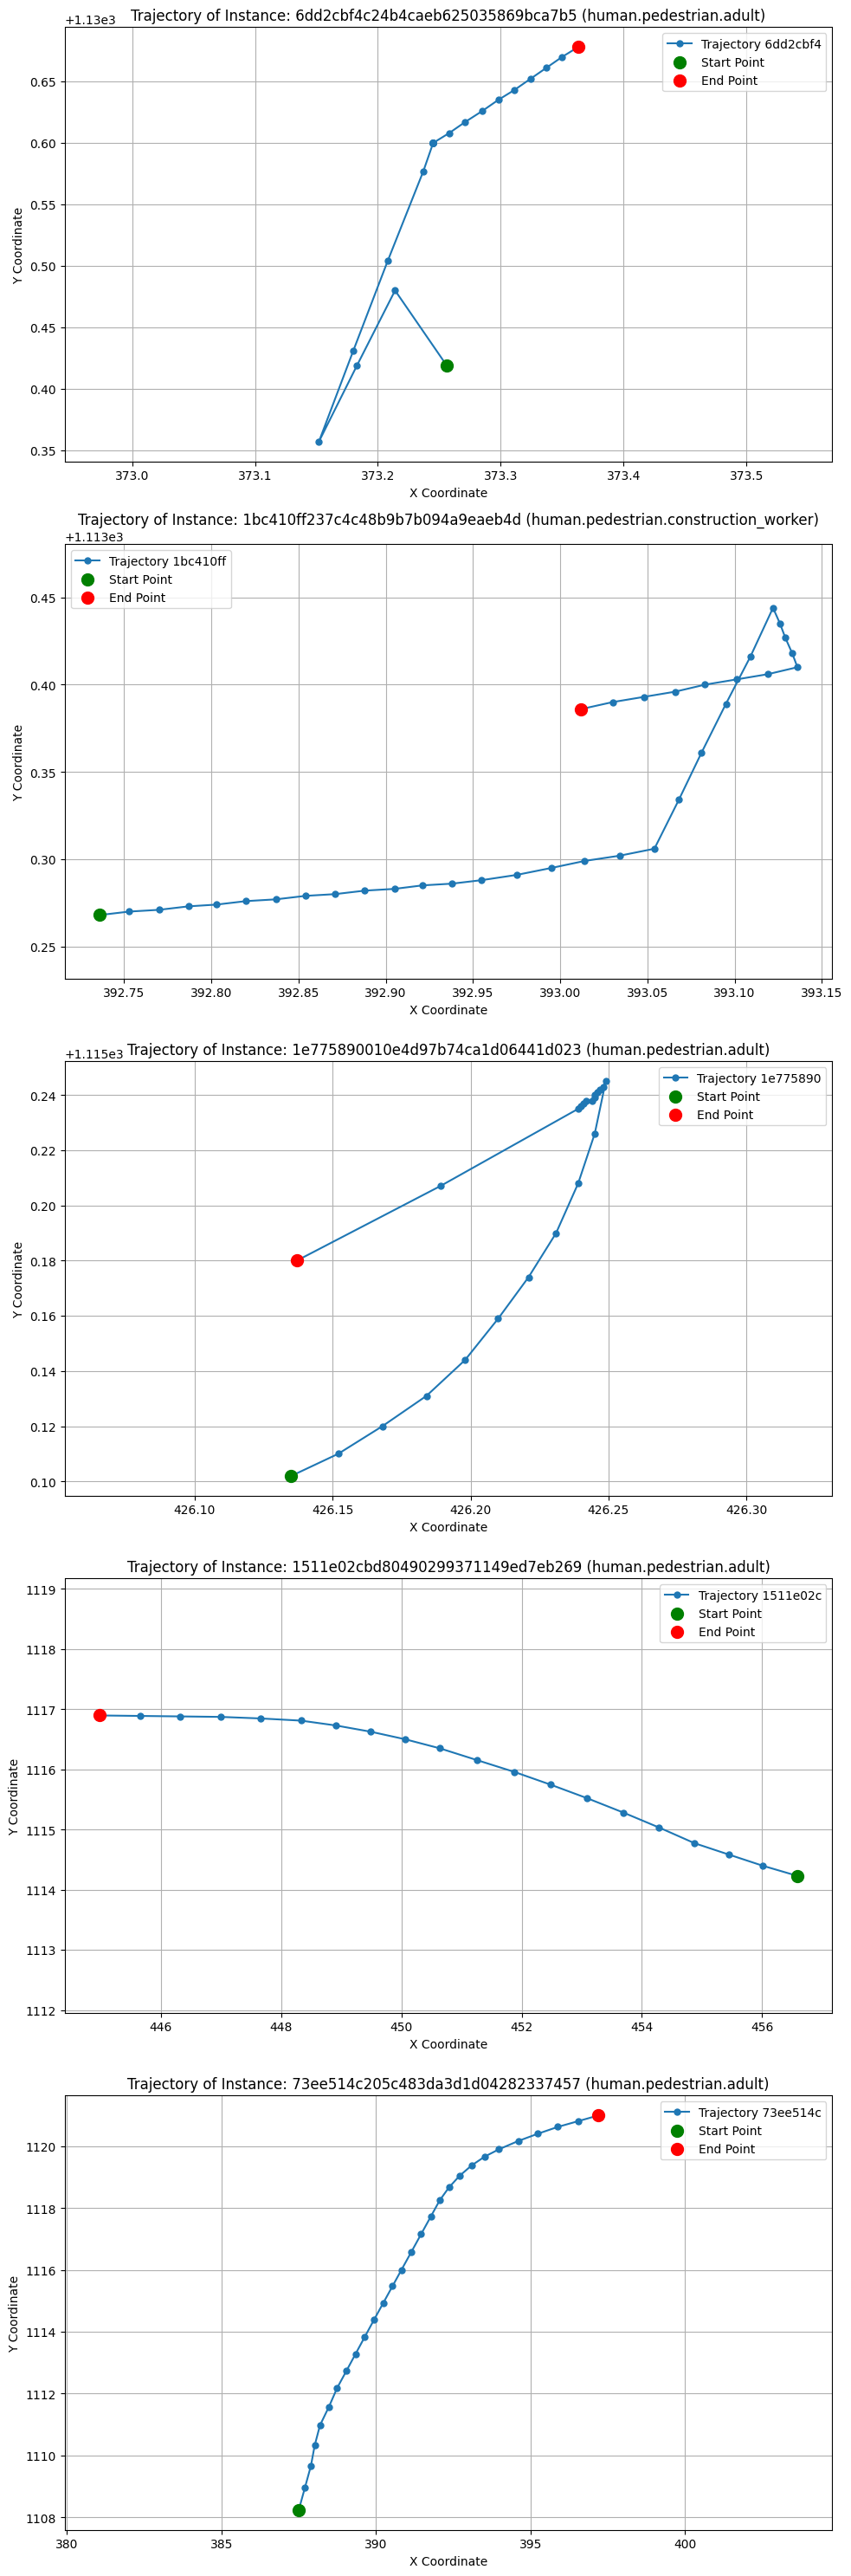

In [49]:
import matplotlib.pyplot as plt

if 'all_trajectories' in locals() and all_trajectories:
    num_plots = min(5, len(all_trajectories))
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 6 * num_plots), squeeze=False)
    axes = axes.flatten()

    print(f"Visualizing {num_plots} of {len(all_trajectories)} extracted trajectories:")

    for i, (instance_token, df) in enumerate(all_trajectories.items()):
        if i >= num_plots:
            break

        ax = axes[i]
        ax.plot(df['x'], df['y'], marker='o', linestyle='-', markersize=5, label=f'Trajectory {instance_token[:8]}')
        ax.scatter(df['x'].iloc[0], df['y'].iloc[0], color='green', s=100, zorder=5, label='Start Point')
        ax.scatter(df['x'].iloc[-1], df['y'].iloc[-1], color='red', s=100, zorder=5, label='End Point')
        ax.set_title(f"Trajectory of Instance: {instance_token} ({df['category_name'].iloc[0]})")
        ax.set_xlabel("X Coordinate")
        ax.set_ylabel("Y Coordinate")
        ax.grid(True)
        ax.legend()
        ax.axis('equal')

    plt.tight_layout()
    plt.show()
else:
    print("No multiple trajectory data found in 'all_trajectories'. Please run the trajectory extraction cells first.")

Feature Engineering: Velocity and Acceleration Calculation

In [50]:
import numpy as np

for instance_token, df in all_trajectories.items():
    df = df.sort_values(by='timestamp_s').reset_index(drop=True)

    df['dt'] = df['timestamp_s'].diff().fillna(0)

    df['vx'] = df['x'].diff() / df['dt']
    df['vy'] = df['y'].diff() / df['dt']
    df['vz'] = df['z'].diff() / df['dt']

    df[['vx', 'vy', 'vz']] = df[['vx', 'vy', 'vz']].fillna(0)

    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)

    df['ax'] = df['vx'].diff() / df['dt']
    df['ay'] = df['vy'].diff() / df['dt']
    df['az'] = df['vz'].diff() / df['dt']

    df[['ax', 'ay', 'az']] = df[['ax', 'ay', 'az']].fillna(0)

    df['acceleration'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

    all_trajectories[instance_token] = df

print("Calculated velocity and acceleration for all extracted trajectories.")

print("\nFirst instance's trajectory with new features (first 5 points):")
first_instance_token = list(all_trajectories.keys())[0]
display(all_trajectories[first_instance_token].head())

Calculated velocity and acceleration for all extracted trajectories.

First instance's trajectory with new features (first 5 points):


,instance_token,category_name,timestamp_s,x,y,z,dt,vx,vy,vz,speed,ax,ay,az,acceleration
0,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.80,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.81,0.499896,0.0,0.0,0.020004,0.020004,0.0,0.0,0.040017,0.040017
2,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.82,0.550201,0.0,0.0,0.018175,0.018175,0.0,0.0,-0.003324,0.003324
3,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.83,0.499305,0.0,0.0,0.020028,0.020028,0.0,0.0,0.003711,0.003711
4,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.84,0.500444,0.0,0.0,0.019982,0.019982,0.0,0.0,-0.000091,0.000091


Feature Engineering for Social Context

In [51]:
import pandas as pd

all_points_df_list = []
for instance_token, df in all_trajectories.items():
    temp_df = df.copy()
    temp_df['original_instance_token'] = instance_token
    all_points_df_list.append(temp_df)

combined_trajectories_df = pd.concat(all_points_df_list, ignore_index=True)

print(f"Combined DataFrame has {len(combined_trajectories_df)} points.")
display(combined_trajectories_df.head())

Combined DataFrame has 1896 points.


,instance_token,category_name,timestamp_s,x,y,z,dt,vx,vy,vz,speed,ax,ay,az,acceleration,original_instance_token
0,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.80,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,6dd2cbf4c24b4caeb625035869bca7b5
1,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.81,0.499896,0.0,0.0,0.020004,0.020004,0.0,0.0,0.040017,0.040017,6dd2cbf4c24b4caeb625035869bca7b5
2,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.82,0.550201,0.0,0.0,0.018175,0.018175,0.0,0.0,-0.003324,0.003324,6dd2cbf4c24b4caeb625035869bca7b5
3,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.83,0.499305,0.0,0.0,0.020028,0.020028,0.0,0.0,0.003711,0.003711,6dd2cbf4c24b4caeb625035869bca7b5
4,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.84,0.500444,0.0,0.0,0.019982,0.019982,0.0,0.0,-0.000091,0.000091,6dd2cbf4c24b4caeb625035869bca7b5


In [52]:
SOCIAL_RADIUS = 10.0

for instance_token, df in all_trajectories.items():
    df['rel_x_closest'] = 0.0
    df['rel_y_closest'] = 0.0
    df['rel_vx_closest'] = 0.0
    df['rel_vy_closest'] = 0.0
    all_trajectories[instance_token] = df

for target_instance_token, target_df in all_trajectories.items():
    for idx, row in target_df.iterrows():
        current_timestamp = row['timestamp_s']
        current_x = row['x']
        current_y = row['y']

        potential_neighbors = combined_trajectories_df[
            (combined_trajectories_df['timestamp_s'] == current_timestamp) &
            (combined_trajectories_df['original_instance_token'] != target_instance_token)
        ].copy()

        if not potential_neighbors.empty:
            potential_neighbors['distance'] = np.sqrt(
                (potential_neighbors['x'] - current_x)**2 +
                (potential_neighbors['y'] - current_y)**2
            )

            nearby_neighbors = potential_neighbors[potential_neighbors['distance'] <= SOCIAL_RADIUS]

            if not nearby_neighbors.empty:
                closest_neighbor = nearby_neighbors.loc[nearby_neighbors['distance'].idxmin()]

                target_df.loc[idx, 'rel_x_closest'] = closest_neighbor['x'] - current_x
                target_df.loc[idx, 'rel_y_closest'] = closest_neighbor['y'] - current_y
                target_df.loc[idx, 'rel_vx_closest'] = closest_neighbor['vx'] - row['vx']
                target_df.loc[idx, 'rel_vy_closest'] = closest_neighbor['vy'] - row['vy']

    all_trajectories[target_instance_token] = target_df

print("Social features engineered for all trajectories.")
print("First instance's trajectory with new social features (first 5 points):")
first_instance_token = list(all_trajectories.keys())[0]
display(all_trajectories[first_instance_token].head())

Social features engineered for all trajectories.
First instance's trajectory with new social features (first 5 points):


,instance_token,category_name,timestamp_s,x,y,z,dt,vx,vy,vz,speed,ax,ay,az,acceleration,rel_x_closest,rel_y_closest,rel_vx_closest,rel_vy_closest
0,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.80,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.592,-1.172,0.000000,0.000000
1,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.81,0.499896,0.0,0.0,0.020004,0.020004,0.0,0.0,0.040017,0.040017,-0.592,-1.172,0.000000,0.000000
2,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.82,0.550201,0.0,0.0,0.018175,0.018175,0.0,0.0,-0.003324,0.003324,-0.592,-1.172,0.000000,0.000000
3,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.83,0.499305,0.0,0.0,0.020028,0.020028,0.0,0.0,0.003711,0.003711,-0.645,-1.161,-0.106148,0.022031
4,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,373.256,1130.419,0.84,0.500444,0.0,0.0,0.019982,0.019982,0.0,0.0,-0.000091,0.000091,-0.699,-1.150,-0.107904,0.021980


Data Preparation: Generating Sequences for Prediction Models

In [64]:
history_steps = 4
future_steps = 6

features = ['x', 'y', 'vx', 'vy', 'speed', 'rel_x_closest', 'rel_y_closest', 'rel_vx_closest', 'rel_vy_closest']

all_sequences = []

for instance_token, df in all_trajectories.items():
    if len(df) < history_steps + future_steps:
        continue

    for i in range(len(df) - history_steps - future_steps + 1):
        history_sequence = df.iloc[i : i + history_steps][features].values
        future_sequence = df.iloc[i + history_steps : i + history_steps + future_steps][['x', 'y']].values

        all_sequences.append({
            'instance_token': instance_token,
            'history': history_sequence,
            'future': future_sequence
        })

print(f"Generated {len(all_sequences)} sequences from {len(all_trajectories)} instances.")

if all_sequences:
    print("\nFirst generated sequence:")
    print("History shape:", all_sequences[0]['history'].shape)
    print("Future shape:", all_sequences[0]['future'].shape)
    print("History data (first 3 steps):\n", all_sequences[0]['history'][:3])
    print("Future data (first 3 steps):\n", all_sequences[0]['future'][:3])
else:
    print("No sequences were generated.")

Generated 1308 sequences from 66 instances.

First generated sequence:
History shape: (4, 9)
Future shape: (6, 2)
History data (first 3 steps):
 [[-0.63425941  0.44750299 -0.00595573  0.0627328  -1.35695671 -0.32560669
  -0.78386815 -0.00788283  0.00248211]
 [-0.63425941  0.44750299 -0.00595573  0.0627328  -1.32631536 -0.32560669
  -0.78386815 -0.00788283  0.00248211]
 [-0.63425941  0.44750299 -0.00595573  0.0627328  -1.32911691 -0.32560669
  -0.78386815 -0.00788283  0.00248211]]
Future data (first 3 steps):
 [[-0.63425941  0.44750299]
 [-0.63425941  0.44750299]
 [-0.63425941  0.44750299]]


### Data Splitting: Training, Validation, and Test Sets


In [65]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array([s['history'] for s in all_sequences])
y = np.array([s['future'] for s in all_sequences])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Total sequences: {len(all_sequences)}")
print(f"Training sequences: {len(X_train)}")
print(f"Validation sequences: {len(X_val)}")
print(f"Test sequences: {len(X_test)}")

print("\nShapes of the datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Total sequences: 1308
Training sequences: 915
Validation sequences: 196
Test sequences: 197

Shapes of the datasets:
X_train shape: (915, 4, 9)
y_train shape: (915, 6, 2)
X_val shape: (196, 4, 9)
y_val shape: (196, 6, 2)
X_test shape: (197, 4, 9)
y_test shape: (197, 6, 2)


 MDN Loss Function

In [55]:
import tensorflow as tf
import numpy as np

def mdn_loss(y_true, y_pred):




    output_steps = y_true.shape[1]
    output_features = y_true.shape[2]
    num_mixtures = 5

    pi_size = output_steps * num_mixtures
    mu_size = output_steps * output_features * num_mixtures
    sigma_size = output_steps * output_features * num_mixtures

    if (pi_size + mu_size + sigma_size) != y_pred.shape[-1]:
        tf.print(f"Mismatch in expected MDN output dimension. Expected: {pi_size + mu_size + sigma_size}, Got: {y_pred.shape[-1]}")

    pi_logits_flat, mu_flat, sigma_raw_flat = tf.split(y_pred, num_or_size_splits=[pi_size, mu_size, sigma_size], axis=-1)

    pi_logits = tf.reshape(pi_logits_flat, shape=[-1, output_steps, num_mixtures])
    mu = tf.reshape(mu_flat, shape=[-1, output_steps, output_features, num_mixtures])
    sigma_raw = tf.reshape(sigma_raw_flat, shape=[-1, output_steps, output_features, num_mixtures])

    pi = tf.keras.activations.softmax(pi_logits, axis=-1)
    sigma = tf.exp(sigma_raw)

    y_true_expanded = tf.expand_dims(y_true, axis=-1)

    exponent = tf.square(y_true_expanded - mu) / (2 * tf.square(sigma))
    normal_dist = tf.exp(-exponent) / (sigma * tf.sqrt(2.0 * np.pi))

    pdf_components = tf.reduce_prod(normal_dist, axis=2)

    sum_of_pdfs = tf.reduce_sum(pi * pdf_components, axis=-1)

    nll_loss = -tf.math.log(sum_of_pdfs + 1e-8)

    return tf.reduce_mean(nll_loss)

print("MDN custom loss function `mdn_loss` defined.")

MDN custom loss function `mdn_loss` defined.


Model Design: Building a Trajectory Prediction Model

In [62]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_shape = X_train.shape[1:]
output_steps = y_train.shape[1]

output_features = 2

num_mixtures = 5






mdn_output_dim = output_steps * (num_mixtures + 2 * num_mixtures * output_features)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.LSTM(128, activation='tanh', return_sequences=True),
    layers.LSTM(128, activation='tanh'),
    layers.Dense(64, activation='relu'),
    layers.Dense(mdn_output_dim)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=mdn_loss)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 4, 128)         │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 150)            │         9,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,246 (860.34 KB)

 Trainable params: 220,246 (860.34 KB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [66]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Model training complete.")

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5839 - val_loss: -0.8065
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: -1.5264 - val_loss: -2.0341
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -2.4984 - val_loss: -2.6834
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -2.9388 - val_loss: -2.1715
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -3.1459 - val_loss: -3.6015
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -3.5950 - val_loss: -3.5953
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -3.8254 - val_loss: -3.6073
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: -3.7228 - val_loss: -4.0706
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: -4.3260 - val_loss: -4.0541
Epoch 10/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: -4.1740 - val_loss: -4.1526
Epoch 11/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: -4.3407 - val_loss: -4.0132
Epoch 12/200
29/29 ━━━━━━━━━━━━━━━━━

Model Evaluation

In [67]:
import numpy as np
import tensorflow as tf

output_steps = 6
output_features = 2
num_mixtures = 5

loss_nll = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (NLL): {loss_nll:.4f}")

y_pred_raw = model.predict(X_test)

pi_size = output_steps * num_mixtures
mu_size = output_steps * output_features * num_mixtures
sigma_size = output_steps * output_features * num_mixtures

pi_logits_flat, mu_flat, sigma_raw_flat = tf.split(y_pred_raw, num_or_size_splits=[pi_size, mu_size, sigma_size], axis=-1)

pi_logits = tf.reshape(pi_logits_flat, shape=[-1, output_steps, num_mixtures])
mu = tf.reshape(mu_flat, shape=[-1, output_steps, output_features, num_mixtures])

pi = tf.keras.activations.softmax(pi_logits, axis=-1);

num_samples = y_pred_raw.shape[0]

y_pred_trajectories_normalized = np.zeros((num_samples, output_steps, output_features))

for i in range(num_samples):
    for t in range(output_steps):
        max_pi_component_idx = tf.argmax(pi[i, t, :]).numpy()

        y_pred_trajectories_normalized[i, t, 0] = mu[i, t, 0, max_pi_component_idx].numpy()
        y_pred_trajectories_normalized[i, t, 1] = mu[i, t, 1, max_pi_component_idx].numpy()

print(f"\nShape of extracted normalized deterministic predictions: {y_pred_trajectories_normalized.shape}")

y_pred_trajectories = target_scaler.inverse_transform(y_pred_trajectories_normalized.reshape(-1, output_features)).reshape(num_samples, output_steps, output_features)
y_test_original_scale = target_scaler.inverse_transform(y_test.reshape(-1, output_features)).reshape(num_samples, output_steps, output_features);

def calculate_ade_fde(predictions, ground_truth):

    ade_per_sample = np.mean(np.linalg.norm(predictions - ground_truth, axis=2), axis=1)
    ade = np.mean(ade_per_sample)

    fde_per_sample = np.linalg.norm(predictions[:, -1, :] - ground_truth[:, -1, :], axis=1);
    fde = np.mean(fde_per_sample)

    return ade, fde

ade, fde = calculate_ade_fde(y_pred_trajectories, y_test_original_scale)
print(f"Average Displacement Error (ADE) (Deterministic, Original Scale): {ade:.4f}")
print(f"Final Displacement Error (FDE) (Deterministic, Original Scale): {fde:.4f}")

Test Loss (NLL): -5.9324
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

Shape of extracted normalized deterministic predictions: (197, 6, 2)
Average Displacement Error (ADE) (Deterministic, Original Scale): 3.2123
Final Displacement Error (FDE) (Deterministic, Original Scale): 3.0146


### Data Normalization

In [59]:
from sklearn.preprocessing import StandardScaler

features = ['x', 'y', 'vx', 'vy', 'speed', 'rel_x_closest', 'rel_y_closest', 'rel_vx_closest', 'rel_vy_closest']

target_features = ['x', 'y']

all_points_for_scaling = pd.concat([df.copy() for df in all_trajectories.values()], ignore_index=True)

feature_scaler = StandardScaler()

all_points_for_scaling[features] = feature_scaler.fit_transform(all_points_for_scaling[features])

target_scaler = StandardScaler()


original_all_points = pd.concat([df_orig.copy() for df_orig in all_trajectories.values()], ignore_index=True)
target_scaler.fit(original_all_points[target_features])

for instance_token, df in all_trajectories.items():
    df_copy = df.copy()
    df_copy[features] = feature_scaler.transform(df_copy[features])
    all_trajectories[instance_token] = df_copy

print("Input and target features have been normalized using StandardScaler.")
print("First instance's trajectory with normalized features (first 5 points):")
first_instance_token = list(all_trajectories.keys())[0]
display(all_trajectories[first_instance_token].head())

Input and target features have been normalized using StandardScaler.
First instance's trajectory with normalized features (first 5 points):


,instance_token,category_name,timestamp_s,x,y,z,dt,vx,vy,vz,speed,ax,ay,az,acceleration,rel_x_closest,rel_y_closest,rel_vx_closest,rel_vy_closest
0,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,-0.634259,0.447503,0.80,0.000000,-0.005956,0.062733,0.000000,-1.356957,0.0,0.0,0.000000,0.000000,-0.325607,-0.783868,-0.007883,0.002482
1,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,-0.634259,0.447503,0.81,0.499896,-0.005956,0.062733,0.020004,-1.326315,0.0,0.0,0.040017,0.040017,-0.325607,-0.783868,-0.007883,0.002482
2,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,-0.634259,0.447503,0.82,0.550201,-0.005956,0.062733,0.018175,-1.329117,0.0,0.0,-0.003324,0.003324,-0.325607,-0.783868,-0.007883,0.002482
3,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,-0.634259,0.447503,0.83,0.499305,-0.005956,0.062733,0.020028,-1.326279,0.0,0.0,0.003711,0.003711,-0.354767,-0.776305,-0.224033,0.058461
4,6dd2cbf4c24b4caeb625035869bca7b5,human.pedestrian.adult,1.532403e+09,-0.634259,0.447503,0.84,0.500444,-0.005956,0.062733,0.019982,-1.326349,0.0,0.0,-0.000091,0.000091,-0.384477,-0.768741,-0.227609,0.058333


Visualizing Predictions

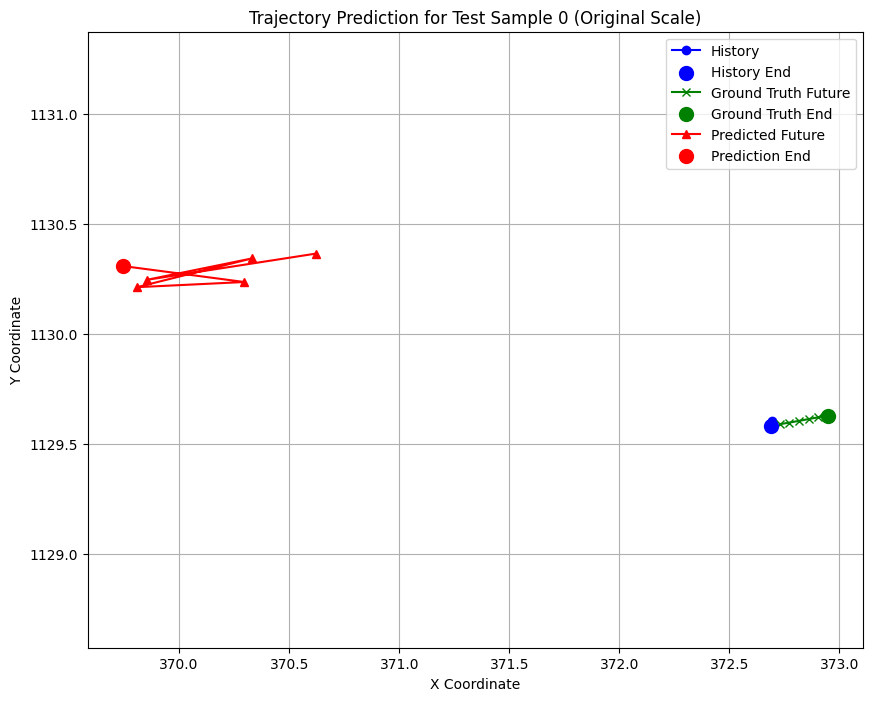

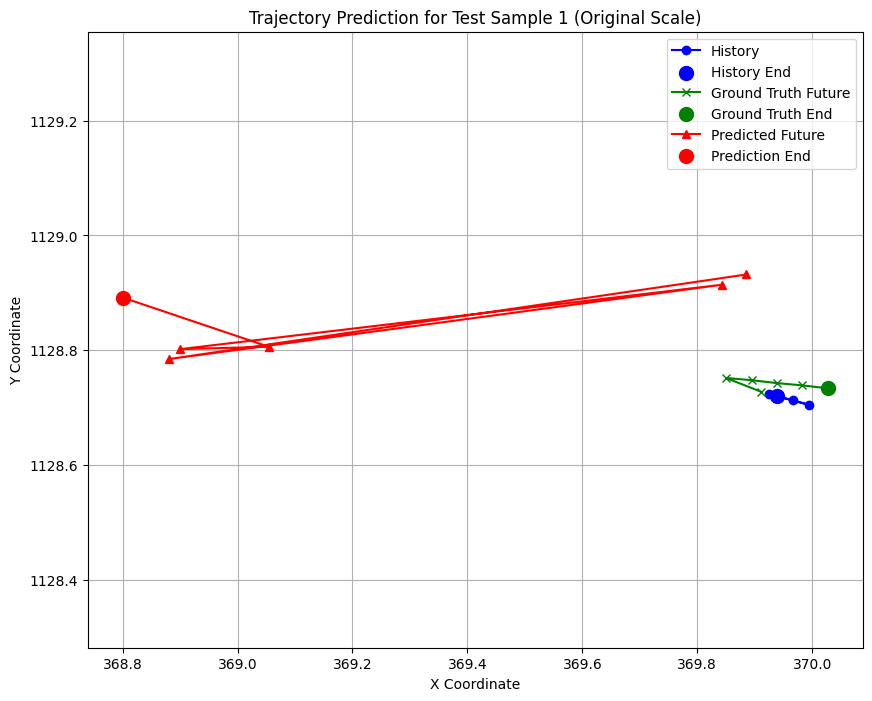

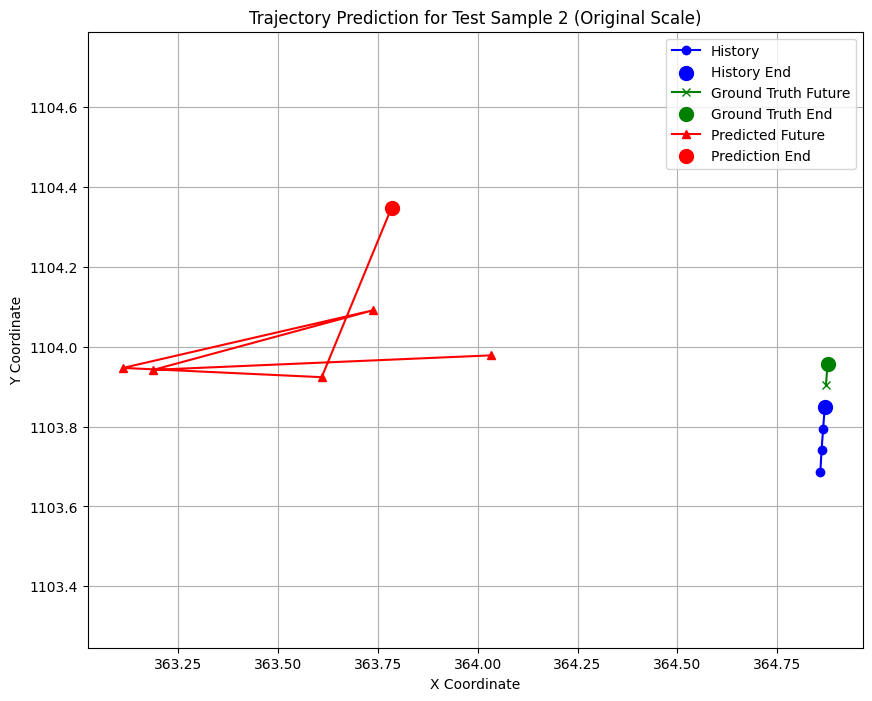

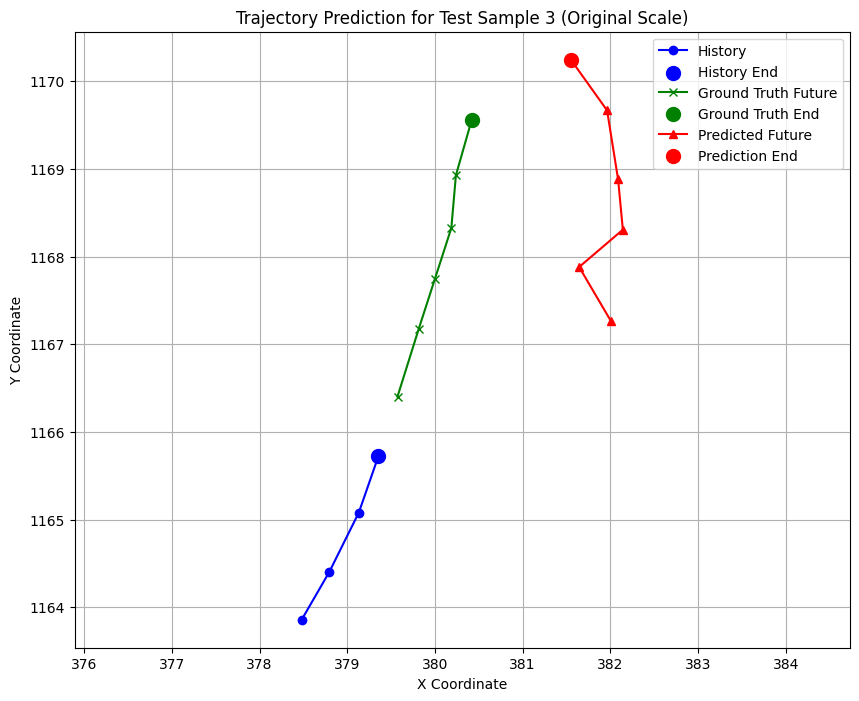

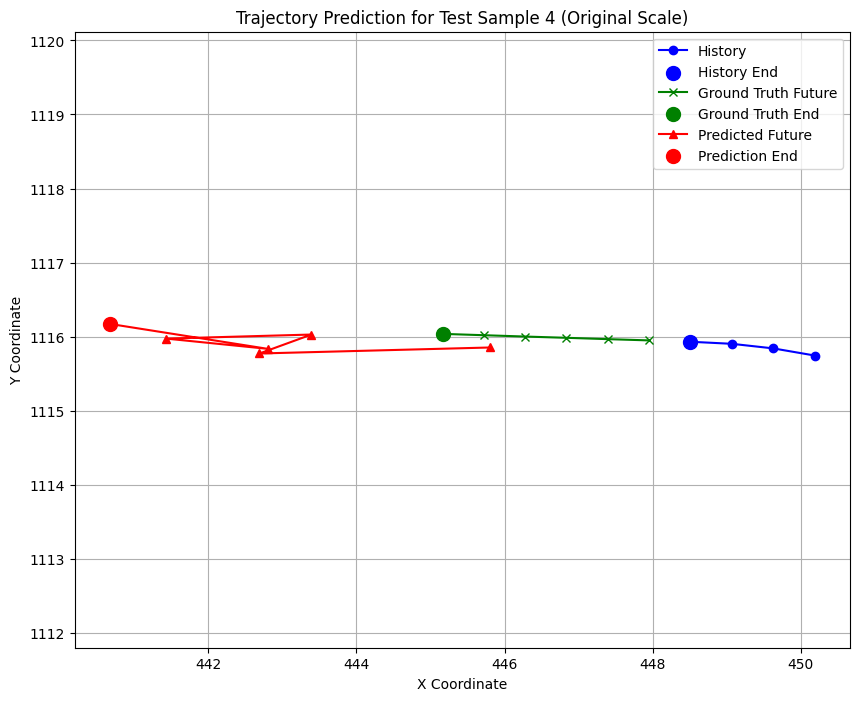

In [68]:
import matplotlib.pyplot as plt

def plot_trajectory_prediction(history_normalized, ground_truth_normalized, prediction_normalized, sample_idx):
    history_original = feature_scaler.inverse_transform(history_normalized)
    ground_truth_original = target_scaler.inverse_transform(ground_truth_normalized)
    prediction_original = target_scaler.inverse_transform(prediction_normalized)

    plt.figure(figsize=(10, 8))

    plt.plot(history_original[:, 0], history_original[:, 1], 'o-', color='blue', label='History')
    plt.scatter(history_original[-1, 0], history_original[-1, 1], color='blue', s=100, zorder=5, label='History End')

    plt.plot(ground_truth_original[:, 0], ground_truth_original[:, 1], 'x-', color='green', label='Ground Truth Future')
    plt.scatter(ground_truth_original[-1, 0], ground_truth_original[-1, 1], color='green', s=100, zorder=5, label='Ground Truth End')

    plt.plot(prediction_original[:, 0], prediction_original[:, 1], '^-', color='red', label='Predicted Future')
    plt.scatter(prediction_original[-1, 0], prediction_original[-1, 1], color='red', s=100, zorder=5, label='Prediction End')

    plt.title(f"Trajectory Prediction for Test Sample {sample_idx} (Original Scale)")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()

num_examples_to_plot = 5

for i in range(num_examples_to_plot):
    plot_trajectory_prediction(
        X_test[i],
        y_test[i],
        y_pred_trajectories_normalized[i],
        i
    )